In [ ]:
# Class
import numpy as np
from mpo import Mpo

class TFI1DNN(Mpo):
    """TFI1DNN: 1D transverse-field Ising model MPO builder.

    Builds Pauli operators and the site-local MPO tensors for a one-dimensional
    nearest-neighbor transverse-field Ising Hamiltonian of the form
    H = -sum_i J[i] X_i X_{i+1} + sum_i h[i] Z_i.

    Parameters:
        sites (int): number of lattice sites.
        local_dim (int): local Hilbert-space dimension (default 2).
        mpo_dim (int): MPO bond dimension used when constructing W tensors.

    Attributes:
        Id, X, Z (np.ndarray): Pauli matrices used to build MPOs.
        name (str): model identifier.
        comment (str): brief description of the model.
        params (dict): expects 'J' and 'h' as lists of length == sites.

    Usage example:
        tfi = TFI1DNN(sites=4)
        tfi.params['J'] = [1.0]*4
        tfi.params['h'] = [0.5]*4
        tfi.init_mpo()  # populates tfi.W_list with MPO tensors

    Notes:
        - __init__ intentionally avoids heavy computations; use init_mpo() to build MPOs.
        - Input validation (e.g. length checks for J and h) should be performed by callers or added as needed.
    """

    # pauli matrices needed for our transverse field ising model
    Id = np.eye(2)
    X = np.array([[0.0, 1.0], [1.0, 0.0]])
    Z = np.array([[1.0, 0.0], [0.0, -1.0]])

    def __init__(self, sites=None, local_dim=2, mpo_dim=3):
        Mpo.__init__(self)
        self.name = "tfi1dnn"  # name the model
        self.comment = "chain, H= -J*X_i X_{i+1} + h*Z_i"  # a free comment
        self.params = {
            "J": [],  # magnetic coupling
            "h": [],  # transverse field
        }
        self.wdim = mpo_dim
        self.ldim = local_dim
        self.sites = sites

    def init_mpo(self):
        """Initializing the list with matrix product operators."""
        # alias for common variables
        D = self.wdim
        d = self.ldim
        J = self.params["J"]
        h = self.params["h"]
        # init matrix product operator
        for i in range(self.sites):
            W = np.zeros((D, D, d, d), dtype=complex)
            W[0, 0:] = [self.Id, -J[i] * self.X, h[i] * self.Z]
            W[1:, 2] = [self.X, self.Id]
            self.W_list.append(W)

In [ ]:
model = TFI1DNN(sites=4)
model.params['J'] = [1.0]*4
model.params['h'] = [0.5]*4
model.init_mpo()

In [ ]:
import numpy as np
from scipy import integrate

h = 0.5

def f(k, h):
    return -2*np.sqrt(1+h**2-2*h*np.cos(k))/np.pi/2.
E0_exact = integrate.quad(f, 0, np.pi, args=(h,))[0]
print(E0_exact, "(EXACT)")

Sites: ((0,), (1,), (2,), (3,))
Bonds: (((0,), (1,)), ((0,), (-1,)), ((1,), (0,)), ((1,), (2,)), ((2,), (1,)), ((2,), (3,)), ((3,), (2,)), ((3,), (4,)))
Vertices: {0: (0,), 1: (1,), 2: (2,), 3: (3,), 4: (-1,), 5: (4,)}
Edges: {0: (0, 1), 1: (0, 4), 2: (1, 0), 3: (1, 2), 4: (2, 1), 5: (2, 3), 6: (3, 2), 7: (3, 5)}


IndexError: index 1 is out of bounds for axis 1 with size 1

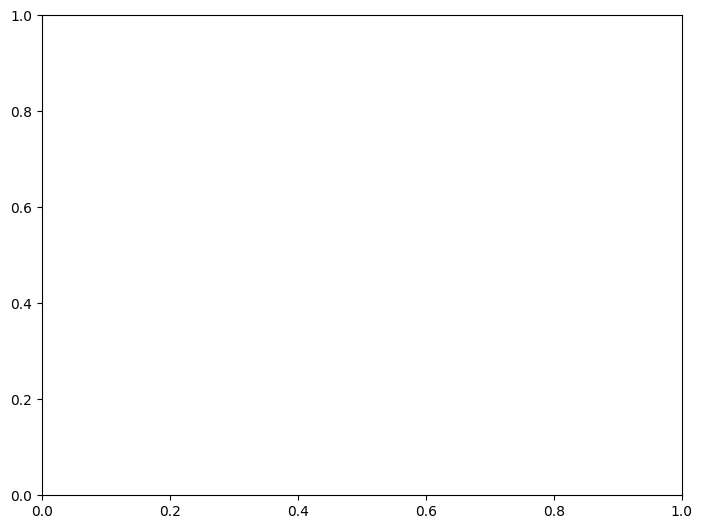

In [1]:
from latticegraph import LatticeGraph

# 1D chain, 4 sites, OBC
chain_obc = LatticeGraph(
    kind="chain",
    sites=(4,),
    unitcell=[((-1,), (+1,))],
    bcs=("obc",)
)

print("Sites:", chain_obc.sites_position)
print("Bonds:", chain_obc.bonds)
print("Vertices:", chain_obc.vertex_dict)
print("Edges:", chain_obc.edge_dict)

chain_obc.plot_graph()

# 1. Introduction: Ground State Calculation, 1D NN transverse field ising model

In [ ]:
import numpy as np
from scipy import integrate

from latticegraph import LatticeGraph
from tensornetwork import TensorNetwork
from mps import Mps
from dmrg import DMRG


if __name__=="__main__":

    # Model
    N = 4                            # number of sites
    tfi = TFI1DNN(sites=N)           # predefined model object
    J = [1.0]*N                      # set interaction as list
    h = [0.5]*N                      # set magnetic field as list
    tfi.params["J"] = J              # set the interaction strength
    tfi.params["h"] = h              # set the magnetic field
    
    # State
    st = Mps(sites=N)             # inifinite two-site dmrg state object
    st.init_mps_random()          # initilize a random matrix product state
    
    # Lattice
    lg = LatticeGraph(comment="chain", sites=(4,), unitcell=[(-1), (+1)], bcs=("obc",))
    
    # Tensor network
    network = TensorNetwork(lg, st, tfi)
    
    # Simulation
    sim = DMRG()   # inifnite two-site dmrg simulation object
    sim.init_env()                   # initilize the corresponding environments                 
    sim.run(True, 1)                 # run the simulation, print data to cli every step
    
    # Exact ground state energy for comparsion
    def f(k, h):
        return -2*np.sqrt(1+h**2-2*h*np.cos(k))/np.pi/2.
    E0_exact = integrate.quad(f, 0, np.pi, args=(h,))[0]
    print(E0_exact, "(EXACT)")

In [ ]:
""" 2. Phase Diagram: 1D transverse field ising model """

import numpy as np
from scipy import integrate
import datetime as dt

import sys
sys.path.append("C:/Users/MircoMarahrens/git/tensor-network-bundle") # set the path to tnb

from tnb.algorithm.dmrg import DMRG
from simulations.tfi.tfi0_class import TFI1DNN

if __name__=="__main__":

    # Model
    tfi = TFI1DNN(sites=4)                                   # predefined model object
    tfi.params["J"] = [1.0]; J = 1.0                         # append interaction to list
    tfi.params["h"] = list(np.linspace(0.1, 0.9, 9)) + \
                      list(np.linspace(1.1,2.0, 10))         # transverse field

    # Exact ground state energy
    f = lambda k,h: -2*np.sqrt(1+h**2-2*h*np.cos(k))/np.pi/2.

    # Flag for date and time
    dt_flag = dt.datetime.now().strftime("%Y%m%d_%H%M%S")

    # Simulation
    with open("data/phasediagram" + dt_flag + ".p", "wb") as file:
        sim = DMRG(model = tfi)                             # initilize idmrg simulation object
        sim.init_iterables()                                 # initilize iterable list idmrg
        sim.chi_max = 1000                                   # set max bond dimenson
        sim.N_max = 100                                      # set max simulation steps
        sim.disc_weight = 1e-12                              # set the discarded weight

        # Data storage
        sim.data.datafile = file                             # set the data file
        sim.data.dump_data(sim.simulation_dict())            # dump simulation data to file
        for h in tfi.params["h"]:
            h = round(h,2)
            sim.init_mps()                                   # initilize/reset mps
            sim.model.init_mpo(J, h)                         # initilize/reset matrix product operator
            sim.init_env()                                   # initilize/reset environments
            sim.run()                                        # run the simulation
            sim.data.dump_data(sim.collect_data())           # collect data and dump it to file as dictionary

            E0_exact = integrate.quad(f, 0, np.pi, args=(h,))[0]
            print(E0_exact, "(EXACT)")


In [ ]:
""" 3. Observables: Calculate Magnetization, 1D transverse field ising model """

import numpy as np
from scipy import integrate
import pickle # object serialization, to load data
import matplotlib.pyplot as plt

import sys
sys.path.append("/home/mmarahrens/tensor-network-bundle") # set the path to tnb

def loadfile(filename):
    data = []
    with open(filename, "rb") as f:
        while True:
            try:
                #yield pickle.load(f)
                data.append(pickle.load(f))
            except EOFError:
                break
    return data

if __name__=="__main__":
    
    # load precalculated data, see tfi2_phasediagram
    data = loadfile("data/phasediagram20181008_144224.p")
    
    # Exact ground state energy
    f = lambda k,h: -2*np.sqrt(1+h**2-2*h*np.cos(k))/np.pi/2.
    E0_exact = integrate.quad(f, 0, np.pi, args=(h,))[0]
    print(E0_exact, "(EXACT)")

In [ ]:
""" 4. Script Correlation length Calculations for: transverse field ising model, chain """

import pickle

from tnb.state.mps import correlation_length



if __name__=="__main__":
    
    # Open datafile and read in data
    data = loadall("data/phasediagram20181002_112602.p")

In [ ]:
""" 5. Script Ground State Calculations for: transverse field ising model, chain """

import numpy as np
import sys
import datetime
sys.path.append("/home/mmarahrens/phd/Tensor_Network_Bundle")

from tnb import algorithm, state, operator, TFI1DNN, iDMRG, init_pauli

#from operator import init_pauli_matrices

if __name__=="__main__":

    I, X, Y, Z = init_pauli() # initialize pauli operators to calculate observables

    J = 1.0 # magnetic interaction
    h_list = [i*0.1 for i in range(20)] # transverse field
    L = 4 # number of sites
    d = 2 # local dimension

    chi_max = 100 # bond dimenson
    N_max = 100 # simulation steps
    disc_weight = 1e-12 # discarded weight

    # transverse field ising model object
    tfi = TFI1DNN()
    tfi.J = J
    tfi.mpo.sites = tfi.mps.sites = L
    tfi.mpo.local_dim = tfi.mps.local_dim = d

    for h in h_list:
        # transverse field
        tfi.h = h

        # initilize matrix product operator
        tfi.init_mpo()
        A_list, l_list, B_list = tfi.init_random_mps()

        # idmrg simulation object
        sim = iDMRG(model = tfi)
        sim.system.sites = L
        sim.N_max = N_max
        sim.chi_max = chi_max
        sim.disc_weight = disc_weight

        # initilize iterable list for hida idmrg
        sim.system.init_iterables()

        # initilize environments
        Le_list, Re_list = sim.init_env()

        with open("data/phasediagram" + str(round(h,1)) + ".json", "w") as file:
            sim.run(True, 1, file)
